# Setup

In [1]:
from torch_harmonics.cylindrical_harmonics import CylindricalHarmonics

In [34]:
K = 2
L = 3
M = 2
ch = CylindricalHarmonics(K, L, M, num_radii=10, num_phi=36, num_height=10)
ch.Psi.shape

torch.Size([1, 28, 10, 36, 10])

# Plotting the CylindricalHarmonics

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from torch_harmonics import plotting

<Axes3D: >

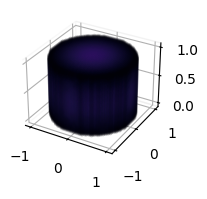

In [4]:
basis_fns = ch.Psi.view(K, L*2+1, M, ch.num_radii, ch.num_phi, ch.num_height)
plotting.plot_cylinder_fn(basis_fns[0,0,0].numpy(), fig=plt.figure(figsize=(2,2)))

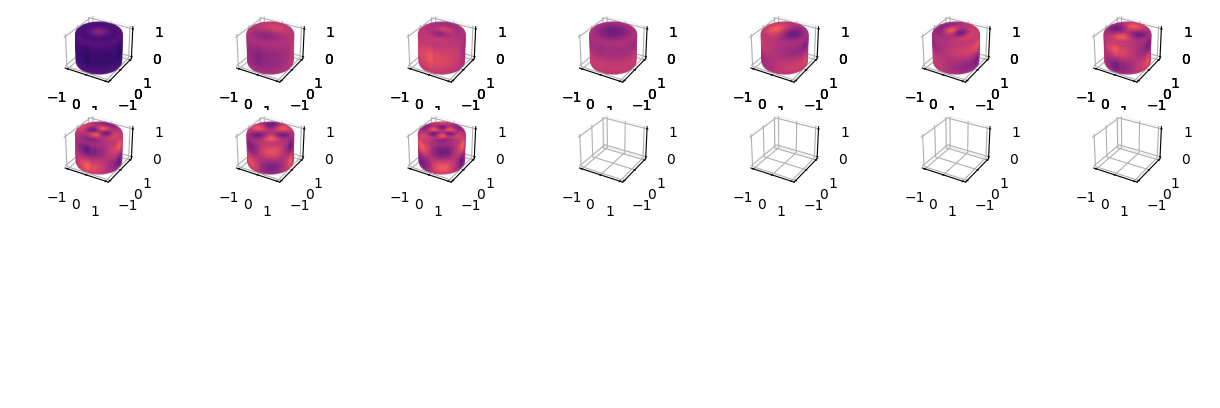

In [36]:
basis_fns = ch.Psi.view(K, L*2+1, M, ch.num_radii, ch.num_phi, ch.num_height)

fig = plt.figure(figsize=(4*L, 2*K))
subfigs = fig.subfigures(K*M, L*2+1)
for m in range(M):
    for k in range(K):
        for l in range(L*2+1):
                plotting.plot_cylinder_fn(basis_fns[k,l,m].numpy(), fig=subfigs[m*k, l])

# Cylindrical Harmonics Transform

In [6]:
import torch
from torch import nn

In [7]:
def f(r, phi, z):
    return r**2 + np.cos(2*phi) - z**2 + r*np.sin(phi)*z

r = torch.linspace(0,1,10)
phi = torch.linspace(0,2*np.pi,36)
z = torch.linspace(0,1,10)
y = f(r[:,None,None], phi[None,:,None], z[None,None,:])

<Axes3D: >

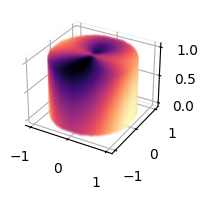

In [8]:
plotting.plot_cylinder_fn(y.numpy(), fig=plt.figure(figsize=(2,2)))

In [19]:
class CHT(nn.Module):
    def __init__(self, K=1, L=3, M=1, num_radii=10, num_phi=36, num_height=10):
        super().__init__()
        self.w_lin = nn.Linear(num_radii * num_phi * num_height, M*K*(L*2+1))
        self.ph = CylindricalHarmonics(K,L,M, num_radii=num_radii, num_phi=num_phi, num_height=num_height)

    def forward(self, x):
        w = self.w_lin(x)
        return self.ph(w), w.detach()

In [32]:
K = 2
L = 3
M = 10
ch_model = CHT(K,L,M)
optimizer = torch.optim.Adam(ch_model.parameters(), lr = 1e-4)

for iter in range(200):
    y_pred, _ = ch_model(y.view(1,-1))
    loss = (y_pred - y).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f'iteration: {iter} loss: {loss.item()}')

iteration: 0 loss: 4.068304538726807
iteration: 10 loss: 0.5381551384925842
iteration: 20 loss: 0.3728357255458832
iteration: 30 loss: 0.2691926956176758
iteration: 40 loss: 0.2519037425518036
iteration: 50 loss: 0.23715725541114807
iteration: 60 loss: 0.23167085647583008
iteration: 70 loss: 0.23063115775585175
iteration: 80 loss: 0.2299775332212448
iteration: 90 loss: 0.22977229952812195
iteration: 100 loss: 0.22974124550819397
iteration: 110 loss: 0.22970795631408691
iteration: 120 loss: 0.2296985238790512
iteration: 130 loss: 0.22969616949558258
iteration: 140 loss: 0.22969476878643036
iteration: 150 loss: 0.2296944409608841
iteration: 160 loss: 0.22969427704811096
iteration: 170 loss: 0.2296942174434662
iteration: 180 loss: 0.2296942174434662
iteration: 190 loss: 0.2296941727399826


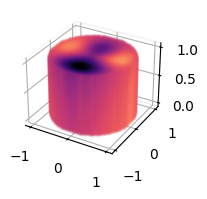

In [33]:
with torch.no_grad():
    pred, w = ch_model(y.view(1,-1))
    plotting.plot_cylinder_fn(pred.squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

In [ ]:
w_ph = torch.einsum("bwrp,bw->bwrp", ph_model.ph.Psi, w).view(K,2*L+1, ph_model.ph.num_radii, ph_model.ph.num_phi)
w.numpy().round(2)

In [ ]:
fig = plt.figure(figsize=(2*L, K))
subfigs = fig.subfigures(K, L*2+1)
for k in range(K):
    for l in range(L*2+1):
            plotting.plot_polar_fn(w_ph[k,l].numpy(), fig=subfigs[k, l])

In [ ]:
basis_fns = ph_model.ph.Psi.view(K, L*2+1, ph.num_radii, ph.num_phi)

fig = plt.figure(figsize=(2*L, K))
subfigs = fig.subfigures(K, L*2+1)
for k in range(K):
    for l in range(L*2+1):
            plotting.plot_polar_fn(basis_fns[k,l].numpy(), fig=subfigs[k, l])